# Variational inference (VI) for fitting GPs

**Author:** Tara Hameed

## Contents
* [Introduction](#introduction)
* [What is VI?](#what-is-vi)
    + [When is it needed?](#when-is-it-needed)
* [Fitting a GP with VI](#fitting-a-gp-with-vi)
* [References](#references)

## Introduction 
This tutorial aims to introduce fitting GPs using VI in `GPflow`. Similar to the other notebook (`01_classical_gpr.ipynb`), the goal of this notebook is not to be an in-depth introduction to using VI to fit GPs but instead a more practical guide and to give an intuition on when using VI is appropriate and how to do so in `GPflow`. All the explanations closely follow those of (Blei _et al_. 2017) and (Leibfried _et al_. 2020) and please refer to these references for a more detailed explanation on the theory behind VI and VI for GPs. All examples also follow advice given in the [GPflow documentation](https://gpflow.github.io/GPflow/2.9.1/notebooks/getting_started/classification_and_other_data_distributions.html).

The notebook starts by calling in the relevant packages:

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import seaborn as sns
import pandas as pd

import gpflow

np.random.seed(32947834);

## What is VI?  

This section gives a mathematical overview of what [VI](https://en.wikipedia.org/wiki/Variational_Bayesian_methods) is. Complete understanding of the mathematical details are not needed for the notebook so feel free to skip this section if you are not interested. Again, all details in this section closely follow those in (Blei _et al_. 2017) and (Leibfried _et al_. 2020).

VI is a technique used to approximate the GP posterior, $p_{\boldsymbol{\theta}}(\boldsymbol{f} | \boldsymbol{y}, X)$, by finding the approximate density, $q(\boldsymbol{f})$, out of a family of chosen approximate densities, $\mathcal{Q}$, which minimises the [Kullback-Leibler](https://en.wikipedia.org/wiki/Kullback–Leibler_divergence) (KL) divergence to the posterior: 

$$\tilde{q}(\boldsymbol{f}) = \argmin_{q(\boldsymbol{f})\in \mathcal{Q}}\text{KL}\left(q(\boldsymbol{f})||p_{\boldsymbol{\theta}}(\boldsymbol{f}|\boldsymbol{y}, X)\right),$$

where, now the dependence on the hyper-parameters, $\boldsymbol{\theta}$, of the posterior are shown as subscripts for notational ease. The KL divergence to be minimised is:
$\begin{align}
    \text{KL}\left(q(\boldsymbol{f})||p_{\boldsymbol{\theta}}(\boldsymbol{f}|\boldsymbol{y}, X)\right) &= \mathbb{E}_q\left[\log \frac{q(\boldsymbol{f})}{p_{\boldsymbol{\theta}}(\boldsymbol{f}|\boldsymbol{y}, X)}\right] \\
    &= \mathbb{E}_q\left[\log q(\boldsymbol{f}) - \log p_{\boldsymbol{\theta}}(\boldsymbol{f}|\boldsymbol{y}, X) \right] \\
    &= \mathbb{E}_q\left[\log q(\boldsymbol{f})\right] - \mathbb{E}_q\left[\log p_{\boldsymbol{\theta}}(\boldsymbol{f}|\boldsymbol{y}, X) \right] \\
    &= \mathbb{E}_q\left[\log q(\boldsymbol{f})\right] - \mathbb{E}_q\left[\log p_{\boldsymbol{\theta}}(\boldsymbol{f},\boldsymbol{y}|X) \right] + \log p_{\boldsymbol{\theta}}(\boldsymbol{y}|X).
\end{align}$
However, for non-Gaussian likelihoods the log marginal likelihood, $\log p_{\boldsymbol{\theta}}(\boldsymbol{y}|X)$, or _evidence_, in the last term is intractable! Rearranging for this term:
$\begin{align}
    \log p_{\boldsymbol{\theta}}(\boldsymbol{y}|X) &= \text{KL}\left(q(\boldsymbol{f})||p_{\boldsymbol{\theta}}(\boldsymbol{f}|\boldsymbol{y}, X)\right)  + \mathbb{E}_q\left[\log p_{\boldsymbol{\theta}}(\boldsymbol{f},\boldsymbol{y}|X) \right] - \mathbb{E}_q\left[\log q(\boldsymbol{f})\right] \\
     &= \text{KL}\left(q(\boldsymbol{f})||p_{\boldsymbol{\theta}}(\boldsymbol{f}|\boldsymbol{y}, X)\right)  + \text{ELBO}(q, \boldsymbol{\theta})
\end{align}$
we see that now we can express the expected log marginal likelihood as a sum of the KL divergence between the approximate density $q(\boldsymbol{f})$ and the posterior and a newly introduced term called the evidence lower bound (ELBO), where the ELBO is defined to be $\mathbb{E}_q\left[\log p_{\boldsymbol{\theta}}(\boldsymbol{f},\boldsymbol{y}|{X}) \right] - \mathbb{E}_q\left[\log q(\boldsymbol{f})\right]$. It is called the ELBO because it lower-bounds $\log p_{\boldsymbol{\theta}}(\boldsymbol y|X)$, $\log p_{\boldsymbol{\theta}}(\boldsymbol y | X) \geq \text{ELBO}(q, \boldsymbol{\theta})$, which follows from the fact that KL divergences are always positive. Moreover, rewriting the KL divergence between $q$ and the posterior in terms of the ELBO:
$$\text{KL}\left(q(\boldsymbol{f})||p_{\boldsymbol{\theta}}(\boldsymbol{f}|\boldsymbol{y}, X)\right) = \log p_{\boldsymbol{\theta}}(\boldsymbol{y}|X) - \text{ELBO}(q, \boldsymbol{\theta})$$

shows that maximising the ELBO minimises the KL. In this way, VI turns **inference** of the posterior into an **optimisation problem** of maximising the ELBO. The ELBO is possible to be computed, provided suitable choice of distribution family $\mathcal{Q}$, and hence can be used to approximate the posterior without needing to know the true form of the posterior. 

### When is it needed? 

VI is used when we need to approximate the posterior, $p_{\boldsymbol{\theta}}(\boldsymbol{f} | \boldsymbol{y}, X)$. The GP analytical results used in the previous notebook `01_classical_gpr.ipynb` only hold when we assume that the data has a _Gaussian likelihood_. In other words, we assume the following model for the data with Gaussian noise: 

$$\boldsymbol{y} = f(\boldsymbol{x}) + \epsilon, \; \epsilon \sim \mathcal{N}(0, \sigma^2 I_n) $$

If we cannot model our data using the above, then we can instead approximate the posterior using VI. An example siutation is where we have count data, for example we want to model the number of defects in a factory, the number of goals scored by a football team or RNAseq data for example. All of these data are non-negative integers and the above formulation is inappropriate.

Let's create some fake count data generated from a Poisson distribution whose mean $\boldsymbol\lambda$ is parametrised using a function of some predictor  $\boldsymbol{x}$ and a log-link: $\log\lambda_i = 2 - \frac{1}{2}x_i^2$. We can generate the fake data $\boldsymbol{y}$ using:

$$ y_i \sim \text{Poisson}\left(e^{(2 - \frac{1}{2}x_i^2)}\right), $$

where the generated $y_i$ s will be integers:


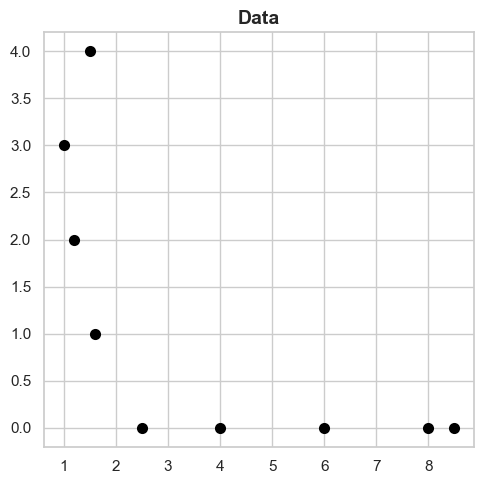

In [3]:
# specify some fake count data:
# 1D input 
Xobs = np.array(
    [
        [1],
        [1.2],
        [1.5],
        [1.6],
        [2.5],
        [4],
        [6],
        [8],
        [8.5],
    ]
)
# poisson parametrised by log-linked quadratic
latent_function = 2-0.5*(Xobs[:, 0]**2)
Yobs = np.random.poisson(np.exp(latent_function), len(Xobs))[:, None].astype(float)  # GPflow takes floats even though the values are ints

# visualise the data
sns.set_theme(style="whitegrid")
plt.figure(figsize=(5, 5))       
plt.plot(Xobs, Yobs, "o", mew=2, color="black", label="Data")
plt.ylabel("")
plt.title("Data", fontsize=14, weight='bold')
plt.tight_layout()

Here we can see how the data is always positive and are only integers. It should be clearer how choosing a Gaussian likelihood would be inappropriate here because a Gaussian likelihood would allow the model to predict negative, non-integer values.

Let's first try to fit a GP to this data using classical GPR explained in `01_classical_gpr.ipynb` to further understand the limitations of modelling the data using a Gaussian likelihood:

In [4]:
# specify GPR model with SquaredExponential kernel on raw count data
gpr_model = gpflow.models.GPR(
    (Xobs, Yobs),
    kernel=gpflow.kernels.SquaredExponential(),
)
# optimise hyperparameters and Gaussian noise
opt = gpflow.optimizers.Scipy()
opt.minimize(gpr_model.training_loss, gpr_model.trainable_variables)
gpflow.utilities.print_summary(gpr_model, "notebook")

name,class,transform,prior,trainable,shape,dtype,value
GPR.kernel.variance,Parameter,Softplus,,True,(),float64,1.39276
GPR.kernel.lengthscales,Parameter,Softplus,,True,(),float64,0.929874
GPR.likelihood.variance,Parameter,Softplus + Shift,,True,(),float64,1.04909


Let's calculate and visualise the predictions over a fine grid of points $X$ on $[0, 10]$: 

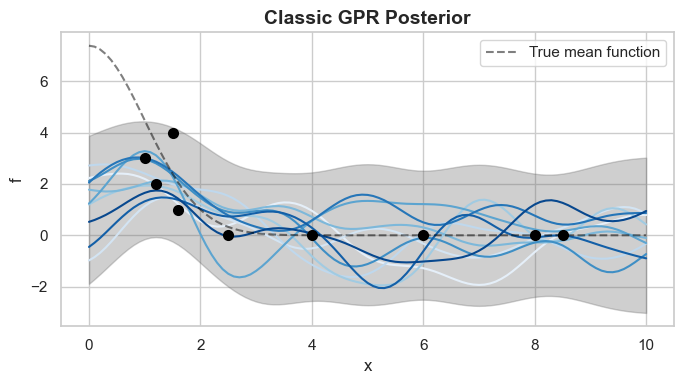

In [5]:
tf.random.set_seed(120394)

# get samples form the posterior predictive
n_samples = 10
X_star = np.linspace(0.0, 10.0, num=101).reshape(-1, 1) 
f_samples = gpr_model.predict_f_samples(X_star, n_samples)
# get mean and variance to plot confidence region
y_mean, y_var = gpr_model.predict_y(X_star, full_cov=False)
f_lower = y_mean - 1.96 * np.sqrt(y_var)
f_upper = y_mean + 1.96 * np.sqrt(y_var)
# put samples and confidence bands into dataframe for plotting
df = pd.DataFrame(f_samples[:, :, 0].numpy().T, columns=[f'Line {i+1}' for i in range(n_samples)])
df.insert(0, "x", X_star[:, 0], allow_duplicates=True)
df = df.melt(id_vars='x', var_name='line', value_name='value')

# plot GP samples
plt.figure(figsize=(7, 4))       
plt.fill_between(
    X_star[:, 0], f_lower[:, 0], f_upper[:, 0], color="#636363", alpha=0.3
)
sns.lineplot(data = df, x = "x", y = "value", palette="Blues", hue="line", linewidth=1.5, legend=False)
sns.lineplot(x = X_star[:, 0], y = np.exp(2-0.5*(X_star[:, 0]**2)), linewidth=1.5, linestyle="--", alpha=0.5, color = "black", label="True mean function")
plt.plot(Xobs, Yobs, "o", mew=2, color="black", label="data")
plt.ylabel("f", fontsize=12)
plt.title("Classic GPR Posterior", fontsize=14, weight='bold')
plt.tight_layout()

The GP fit doesn't look appropriate: it allows for negative values, which are impossible when modelling count data. Additionally, the 95% confidence region does not include the true mean, $\exp(2 - \frac{1}{2}\boldsymbol{x}^2)$, which was specified when generating the fake data! 

To overcome these issues, we want to be able to specify a Poisson likelihood and instead use the GP to model the latent (unknown) mean function.

## Fitting a GP with VI 

`GPflow` uses a using a multivariate Gaussian parametrised with some mean and covariance as the family of approximate densities, $\mathcal{Q}$, and the ELBO is maximised with respect to these variational parameters to find the find the optimal density, $q(\boldsymbol{f})$, that approximates the posterior. Moreover,  VI methods also tend to maximise the ELBO with respect to the GP hyper-parameters, $\boldsymbol{\theta}$, to find the optimal values for the hyper-parameters, $\hat{\boldsymbol{\theta}}$ (Leibfried _et al_. 2020). 

Using VI to fit a GP in `GPflow` is very simple. Instead of calling `GPR` from `gpflow.models`, `VGP` is used and the likelihood (`gpflow.likelihoods.Poisson()`) is specified. Then the variational parameters and hyperparameters are optimised in a similar way as before:

In [6]:
# specify VGP model with SquaredExponential kernel and Poisson likelihood on raw count data
vgp_model = gpflow.models.VGP(
    (Xobs, Yobs),
    kernel=gpflow.kernels.SquaredExponential(),
    likelihood=gpflow.likelihoods.Poisson(),
)
# optimise hyperparameters but also VI parameters
opt = gpflow.optimizers.Scipy()
opt.minimize(vgp_model.training_loss, vgp_model.trainable_variables)
gpflow.utilities.print_summary(vgp_model, "notebook")

name,class,transform,prior,trainable,shape,dtype,value
VGP.kernel.variance,Parameter,Softplus,,True,(),float64,9.7934
VGP.kernel.lengthscales,Parameter,Softplus,,True,(),float64,3.77177
VGP.num_data,Parameter,Identity,,False,(),int32,9
VGP.q_mu,Parameter,Identity,,True,"(9, 1)",float64,[[0.32815182...
VGP.q_sqrt,Parameter,FillTriangular,,True,"(1, 9, 9)",float64,"[[[1.19783254e-01, 0.00000000e+00, 0.00000000e+00..."


We can calculate the latent GP predictions and use the inverse log-link function ($\exp$) to visualise them in the data-space:

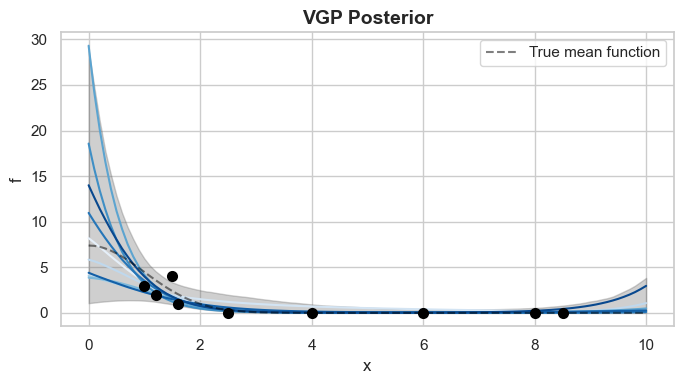

In [7]:
tf.random.set_seed(9596875)

# get latent GP samples
f_samples = vgp_model.predict_f_samples(X_star, n_samples)
# transform latent GP using exp to obtain GP samples in data space
trans_f_samples = vgp_model.likelihood.invlink(f_samples)

# get mean and variance to plot confidence region
f_samples_quantiles = vgp_model.predict_f_samples(X_star, 10000)
trans_f_samples_quantiles = vgp_model.likelihood.invlink(f_samples_quantiles)
f_lower = np.quantile(trans_f_samples_quantiles[:, :, 0], 0.025, axis=0)
f_upper = np.quantile(trans_f_samples_quantiles[:, :, 0], 0.975, axis=0)
# put samples and confidence bands into dataframe for plotting
df = pd.DataFrame(trans_f_samples[:, :, 0].numpy().T, columns=[f'Line {i+1}' for i in range(n_samples)])
df.insert(0, "x", X_star[:, 0], allow_duplicates=True)
df = df.melt(id_vars='x', var_name='line', value_name='value')

# plot GP samples
plt.figure(figsize=(7, 4))       
plt.fill_between(
    X_star[:, 0], f_lower, f_upper, color="#636363", alpha=0.3
)
sns.lineplot(data = df, x = "x", y = "value", palette="Blues", hue="line", linewidth=1.5, legend=False)
sns.lineplot(x = X_star[:, 0], y = np.exp(2-0.5*(X_star[:, 0]**2)), linewidth=1.5, linestyle="--", alpha=0.5, color = "black", label="True mean function")
plt.plot(Xobs, Yobs, "o", mew=2, color="black", label="data")
plt.ylabel("f", fontsize=12)
plt.title("VGP Posterior", fontsize=14, weight='bold')
plt.tight_layout()

This fit to the data is more appropriate: the GP samples do not include negative values and the 95% confidence region includes the true mean function used to generate the data!

## References
Blei DM, Kucukelbir A, McAuliffe JD. Variational inference: A review for statisticians. Journal of the American statistical Association. 2017 Apr 3;112(518):859-77.

Leibfried F, Dutordoir V, John ST, Durrande N. A tutorial on sparse Gaussian processes and variational inference. arXiv preprint arXiv:2012.13962. 2020 Dec 27.